In [6]:
import os
import pandas as pd

BASE_DIR = os.path.abspath("..")

data_path = os.path.join(BASE_DIR, "data")

df = pd.read_csv(os.path.join(data_path, "account_transactions.csv"))
codes = pd.read_csv(os.path.join(data_path, "transaction_codes.csv"))

print(df.shape, codes.shape)

(2377169, 8) (15, 5)


In [7]:
df.head()

,transaction_id,account_id,linked_transaction_id,created_time,transaction_type,transaction_code,amount,channel
0,f5526a0f-4ec2-4aa4-a01e-33034d40ec33,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,NaN,2023-04-21 12:55:00,Credit,IBK_IN,5750.20,InterbankPortal
1,b1c5757f-587d-418b-9238-35c4e338b731,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,NaN,2023-04-22 11:18:00,Credit,IBK_IN,3253.85,InterbankPortal
2,f248fe0e-b646-4df6-a9d8-e8ebcd386c92,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,NaN,2023-04-22 12:16:00,Credit,IBK_IN,1055.74,InterbankPortal
3,44314720-e02d-4c39-8aaf-b0d81380225d,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,NaN,2023-04-22 14:15:00,Debit,CSH_WDL,400.00,Branch
4,9dcabefa-fe70-4d3f-b29e-22c442cba3dd,eb1f2f49-1bc0-45c8-8991-4abea8f7f6ea,NaN,2023-04-22 16:24:00,Debit,CSH_WDL,480.00,Branch


In [8]:
df["created_time"] = pd.to_datetime(df["created_time"])

df["hour"] = df["created_time"].dt.hour
df["day_name"] = df["created_time"].dt.day_name()
df["month"] = df["created_time"].dt.month
df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"])

In [9]:
df["amount_segment"] = pd.qcut(
    df["amount"],
    q=3,
    labels=["Low", "Medium", "High"]
)

digital = ["OnlineBanking", "MobileApp"]
physical = ["ATM", "Branch"]
df["channel_group"] = df["channel"].apply(
    lambda x: "Digital" if x in digital else "Physical" if x in physical else "Other"
)

In [11]:
df["is_high_value"] = df["amount"] > df["amount"].quantile(0.90)

In [12]:
customer_df = df.groupby("account_id").agg({
    "amount": ["sum", "mean", "count"],
    "is_high_value": "sum"
}).reset_index()

In [13]:
df["amount_segment"].value_counts()

amount_segment
Low       813539
High      791371
Medium    772259
Name: count, dtype: int64

In [14]:
def amount_bucket(x):
    if x > 5000:
        return "High Value"
    elif x > 1000:
        return "Mid Value"
    else:
        return "Low Value"

df["amount_segment_real"] = df["amount"].apply(amount_bucket)

In [15]:
df["amount_segment_real"].value_counts()

amount_segment_real
Low Value     1976143
Mid Value      341234
High Value      59792
Name: count, dtype: int64

In [16]:
df.groupby("account_id")["amount"].sum().describe()

count    3.553000e+03
mean     6.095675e+05
std      1.233703e+06
min      5.370200e+02
25%      3.452067e+04
50%      8.579543e+04
75%      5.533318e+05
max      1.298532e+07
Name: amount, dtype: float64

In [17]:
threshold = df.groupby("account_id")["amount"].sum().quantile(0.90)

df["is_vip_customer"] = df.groupby("account_id")["amount"].transform("sum") >= threshold

In [18]:
df.groupby("account_id")["amount"].sum().quantile(0.90)

np.float64(2014834.3700000008)

In [19]:
customer_total = df.groupby("account_id")["amount"].sum().reset_index()

threshold = customer_total["amount"].quantile(0.90)

customer_total["customer_segment"] = customer_total["amount"].apply(
    lambda x: "VIP" if x >= threshold else "Non-VIP"
)

In [20]:
customer_total["customer_segment"].value_counts()

customer_segment
Non-VIP    3197
VIP         356
Name: count, dtype: int64

In [21]:
customer_total.head()

,account_id,amount,customer_segment
0,00136224-1cb2-4f60-8cc5-acbb77ea40c9,153041.50,Non-VIP
1,001a4c3d-28eb-4cc8-b926-f6fe570e575b,872139.78,Non-VIP
2,00248e8b-4c5d-4a71-8d81-8fb80719ff4b,723891.22,Non-VIP
3,0039f27e-6434-47dd-8365-c64ef3ce2bf8,2735353.88,VIP
4,006109e7-0e4a-4fb9-9b98-355faf3dc5be,7545765.02,VIP


In [22]:
customer_total["customer_segment"].value_counts(normalize=True) * 100

customer_segment
Non-VIP    89.980298
VIP        10.019702
Name: proportion, dtype: float64

In [23]:
customer_total.groupby("customer_segment")["amount"].sum()

customer_segment
Non-VIP    8.561625e+08
VIP        1.309631e+09
Name: amount, dtype: float64

In [24]:
customer_total.groupby("customer_segment")["amount"].mean()

customer_segment
Non-VIP    2.678018e+05
VIP        3.678738e+06
Name: amount, dtype: float64

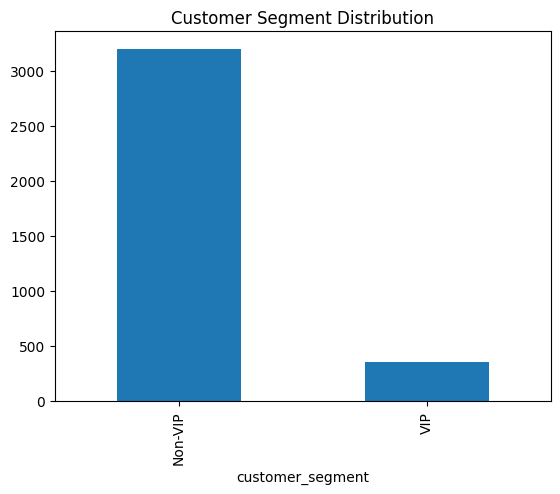

In [25]:
import matplotlib.pyplot as plt

customer_total["customer_segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.show()

In [ ]:
# =========================
# RFM ANALYSIS
# =========================

In [26]:
df["created_time"] = pd.to_datetime(df["created_time"])
snapshot_date = df["created_time"].max()

In [27]:
rfm = df.groupby("account_id").agg({
    "created_time": lambda x: (snapshot_date - x.max()).days,
    "transaction_id": "count",
    "amount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
account_id,,,
00136224-1cb2-4f60-8cc5-acbb77ea40c9,550,2,153041.50
001a4c3d-28eb-4cc8-b926-f6fe570e575b,1,1264,872139.78
00248e8b-4c5d-4a71-8d81-8fb80719ff4b,0,692,723891.22
0039f27e-6434-47dd-8365-c64ef3ce2bf8,1,2206,2735353.88
006109e7-0e4a-4fb9-9b98-355faf3dc5be,1,11963,7545765.02


In [30]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(
    rfm["Frequency"],
    5,
    labels=False,
    duplicates="drop"
) + 1
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [31]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)

In [33]:
def segment(x):
    if x >= 13:
        return "Champions"
    elif x >= 10:
        return "Loyal Customers"
    elif x >= 7:
        return "Potential Loyalists"
    else:
        return "At Risk"

rfm["segment"] = rfm["RFM_score"].apply(segment)

In [34]:
rfm["segment"].value_counts()

segment
At Risk                1541
Potential Loyalists     876
Champions               737
Loyal Customers         399
Name: count, dtype: int64

In [35]:
rfm = rfm.merge(customer_total, on="account_id")

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = rfm[["Recency","Frequency","Monetary"]]

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

In [42]:
rfm.groupby("segment")["Monetary"].mean()

segment
At Risk                5.893584e+04
Champions              2.443161e+06
Loyal Customers        4.630633e+05
Potential Loyalists    1.022843e+05
Name: Monetary, dtype: float64

In [44]:
# =========================
# CUSTOMER SEGMENT VISUALIZATION
# =========================

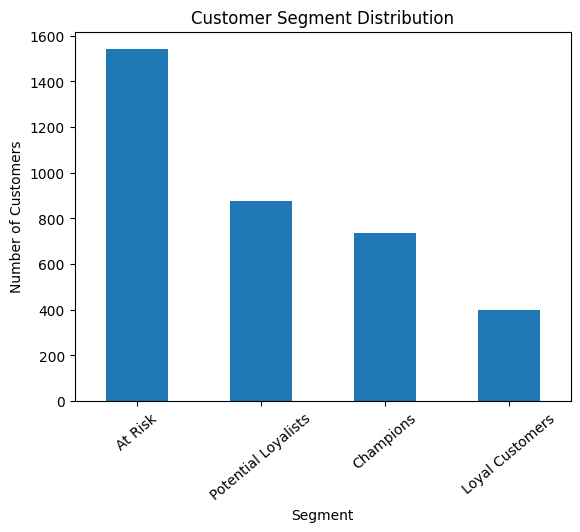

In [49]:
import matplotlib.pyplot as plt

rfm["segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=4000)
plt.show()

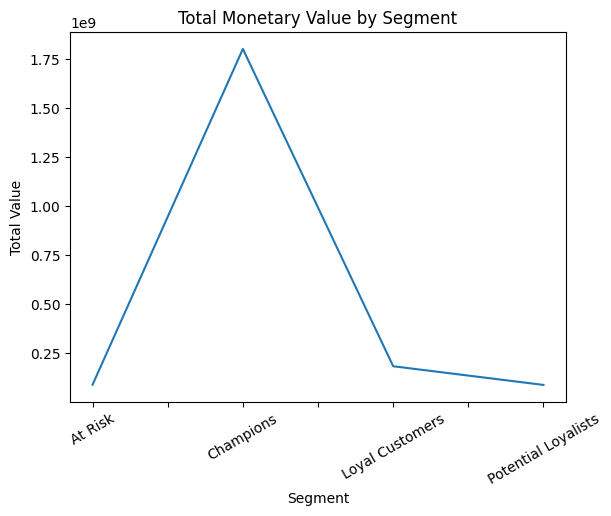

In [52]:
rfm.groupby("segment")["Monetary"].sum().plot(kind="line")
plt.title("Total Monetary Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Value")
plt.xticks(rotation=30)
plt.show()

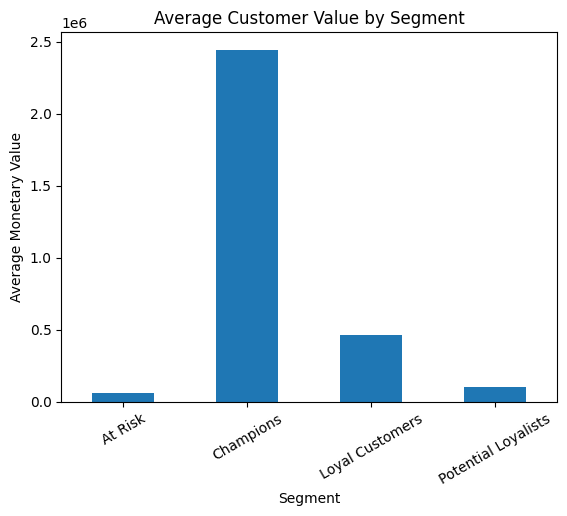

In [53]:
rfm.groupby("segment")["Monetary"].mean().plot(kind="bar")
plt.title("Average Customer Value by Segment")
plt.xlabel("Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=30)
plt.show()

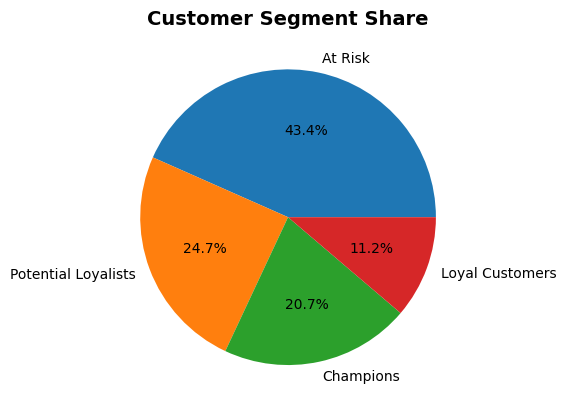

In [65]:
rfm["segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
ax = plt.gca()
ax.set_title("Customer Segment Share", fontsize=14, fontweight="bold")
plt.ylabel("")
plt.show()